# Static visualization first

['BE-LeftRight', 'BG-LeftRight', 'CZ-LeftRight', 'DK-LeftRight', 'DE-LeftRight', 'EE-LeftRight', 'EL-LeftRight', 'ES-LeftRight', 'FR-LeftRight', 'IE-LeftRight', 'IT-LeftRight', 'CY-LeftRight', 'LV-LeftRight', 'LT-LeftRight', 'LU-LeftRight', 'HU-LeftRight', 'MT-LeftRight', 'NL-LeftRight', 'AT-LeftRight', 'PL-LeftRight', 'PT-LeftRight', 'RO-LeftRight', 'SI-LeftRight', 'SK-LeftRight', 'FI-LeftRight', 'SE-LeftRight', 'UK-LeftRight', 'HR-LeftRight']
BE-LeftRight
     0     1     2     3     4     5     6     7     8       9     10      11  \
0  2007  2010  2012  2014  2015  2016  2017  2019  2020  2020.5  2021  2021.5   

     12    13       14      15    16  
0  2022  2023  2024.33  2024.5  2025  
BG-LeftRight
     0     1     2     3     4     5     6     7     8       9     10      11  \
0  2007  2010  2012  2014  2015  2016  2017  2019  2020  2020.5  2021  2021.5   

     12    13       14      15    16  
0  2022  2023  2024.33  2024.5  2025  
CZ-LeftRight
     0     1     2     3     4

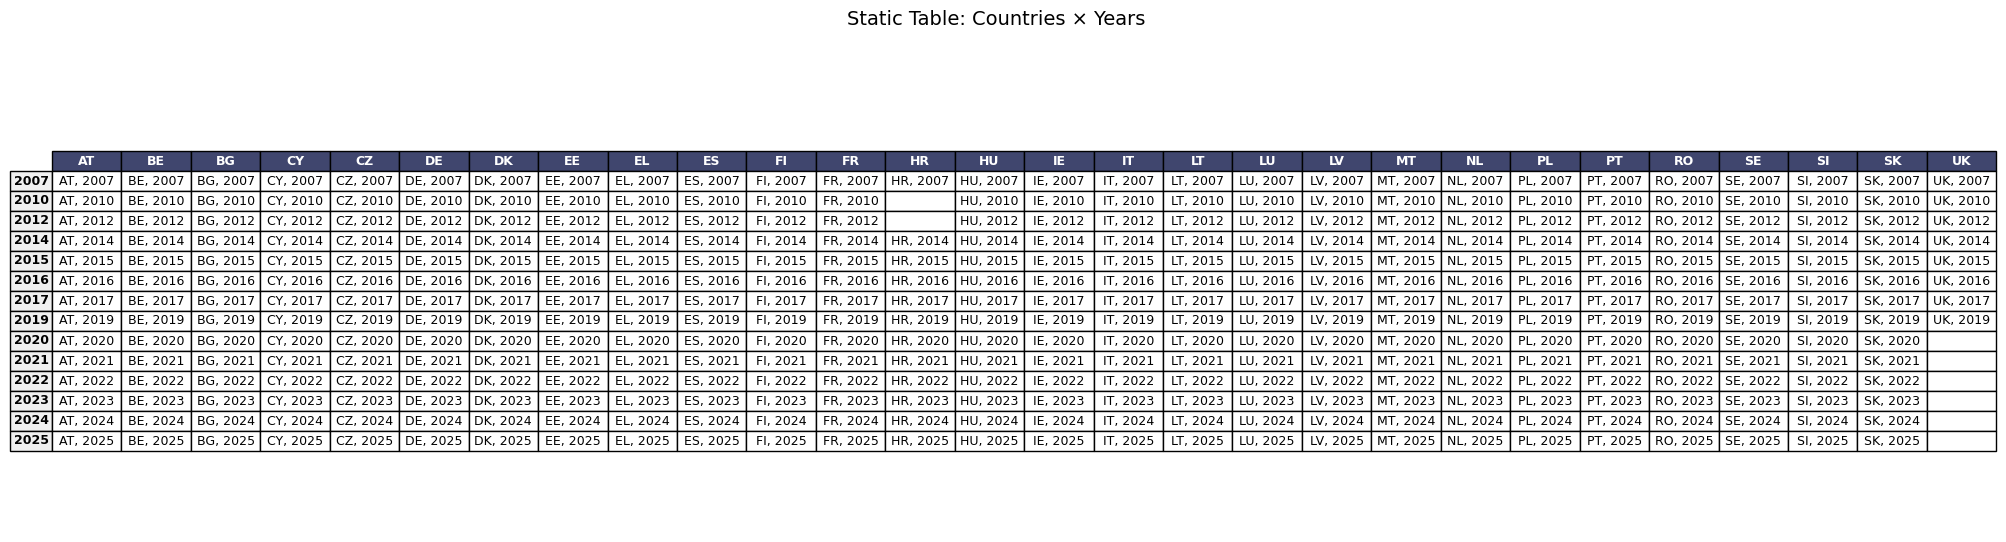

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# 1. Load the Excel file
# -------------------------------
file_path = 'EU_dataset/Cleaned_Parlemeter_Data-LeftRight.xlsx'
sheet_names = pd.ExcelFile(file_path).sheet_names
sheet_names.remove('RowHeader')
print(sheet_names)
# -------------------------------
# 2. Parse countries and years
# -------------------------------
country_years = {}  # country_code -> list of years (from first row of its sheet)

for sheet in sheet_names:
    print(sheet)
    # Extract country code (part before the first '-')
    country = sheet.split('-')[0].strip()
    # Read the sheet, but only the first row to get years
    df_temp = pd.read_excel(file_path, sheet_name=sheet, header=None, nrows=1)
    print(df_temp)
    years = df_temp.iloc[0].dropna().astype(int).tolist()
    country_years[country] = years

# Get all unique years across all countries
all_years = sorted(set().union(*country_years.values()))
countries = sorted(country_years.keys())

# -------------------------------
# 3. Build the table matrix
# -------------------------------
# We'll create a matrix where rows = years, columns = countries
# Each cell will contain a string like "DE, 2014" (for display)
# We'll also store a numeric value if you later want to color by something else.

data_matrix = np.empty((len(all_years), len(countries)), dtype=object)

for i, year in enumerate(all_years):
    for j, country in enumerate(countries):
        # Check if this year exists for this country
        if year in country_years.get(country, []):
            cell_text = f"{country}, {year}"
        else:
            cell_text = ""  # or "—" to indicate missing
        data_matrix[i, j] = cell_text

# -------------------------------
# 4. Create the table plot
# -------------------------------
fig, ax = plt.subplots(figsize=(max(10, len(countries)*0.8), max(6, len(all_years)*0.4)))
ax.axis('off')  # Hide axes

# Create the table
table = ax.table(cellText=data_matrix,
                 rowLabels=all_years,
                 colLabels=countries,
                 loc='center',
                 cellLoc='center',
                 colWidths=[0.1]*len(countries))  # Adjust width as needed

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(0.4, 1.2)  # Adjust scaling to fit

# Make header cells bold and slightly colored
for (row, col), cell in table.get_celld().items():
    if row == 0:  # column headers (countries)
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#40466e')
    elif col == -1:  # row headers (years)
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#f0f0f0')
    else:
        # For data cells, we can later color them dynamically
        # For now, make them white with black text
        cell.set_facecolor('white')
        cell.set_text_props(color='black')

# Add a title
plt.suptitle('Static Table: Countries × Years', fontsize=14, y=0.98)

# Adjust layout and save/show
# plt.tight_layout()
plt.savefig('EU_dataset/staticTable.jpg', dpi = 300)
plt.show()

# Optionally save to file
# fig.savefig('static_table.png', dpi=300, bbox_inches='tight')

# Getting BSearch Data

In [11]:
data_file = 'data/BehaviorSearch-Thresholded/BSearch_threshold_satisfied_distributions-Step7-T-0.15.csv'
bsearch_df_read = pd.read_csv(data_file)

In [12]:
# print(bsearch_df_read)

# We want to clip away at least the first few because we had some file handling issues - we always append after simulation run so if the file isnt deleted we are in a bit of trouble
n_to_clip = 50
bsearch_df =bsearch_df_read.iloc[n_to_clip:]
bsearch_df.rename(columns={bsearch_df.columns[3]: 'matches'}, inplace=True) # To remove the annoyingly long and potentially misleading column name

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17400\3133517218.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bsearch_df.rename(columns={bsearch_df.columns[3]: 'matches'}, inplace=True) # To remove the annoyingly long and potentially misleading column name


In [13]:
bsearch_df

,JSD (pooled),JSD (best),Thresholded counts,matches
50,0.499194,0.402437,0.747563,NaN
51,0.499939,0.397541,0.752459,NaN
52,0.367098,0.242535,0.907465,NaN
53,0.499451,0.398248,0.751752,NaN
54,0.358283,0.232613,0.917387,NaN
...,...,...,...,...
1914,0.132204,0.064808,171.999599,{BE 2007} && {BE 2010} && {BE 2012} && {BE 201...
1915,0.127248,0.049074,188.999926,{BE 2007} && {BE 2010} && {BE 2015} && {BE 201...
1916,0.240614,0.080097,15.998910,{IE 2010} && {IE 2015} && {IE 2016} && {IE 201...
1917,0.278459,0.111152,5.999049,{IE 2021} && {IE 2021} && {IE 2022} && {IE 202...


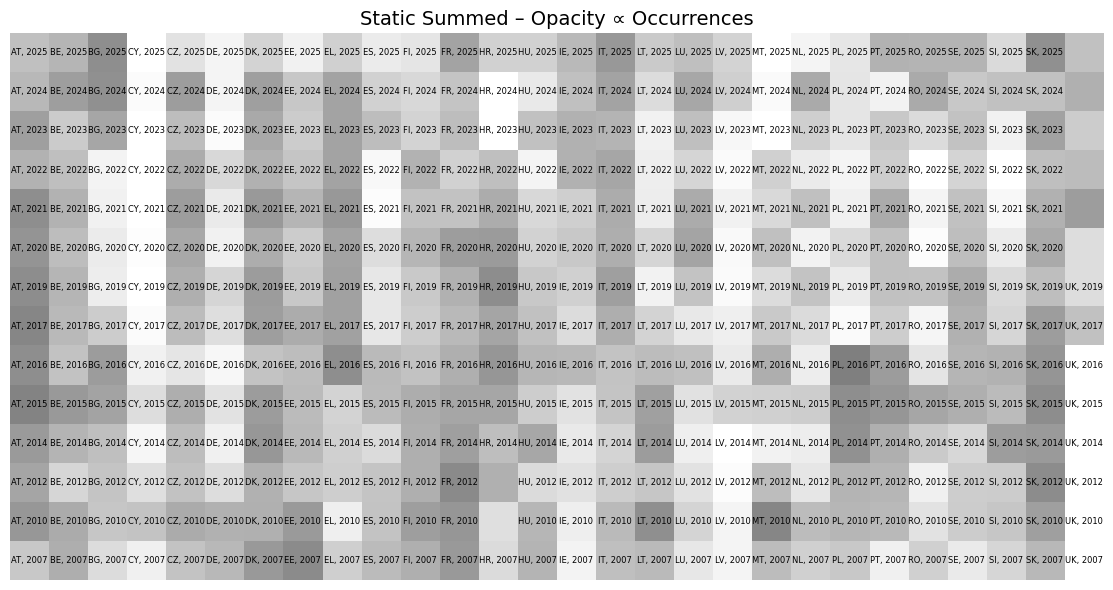

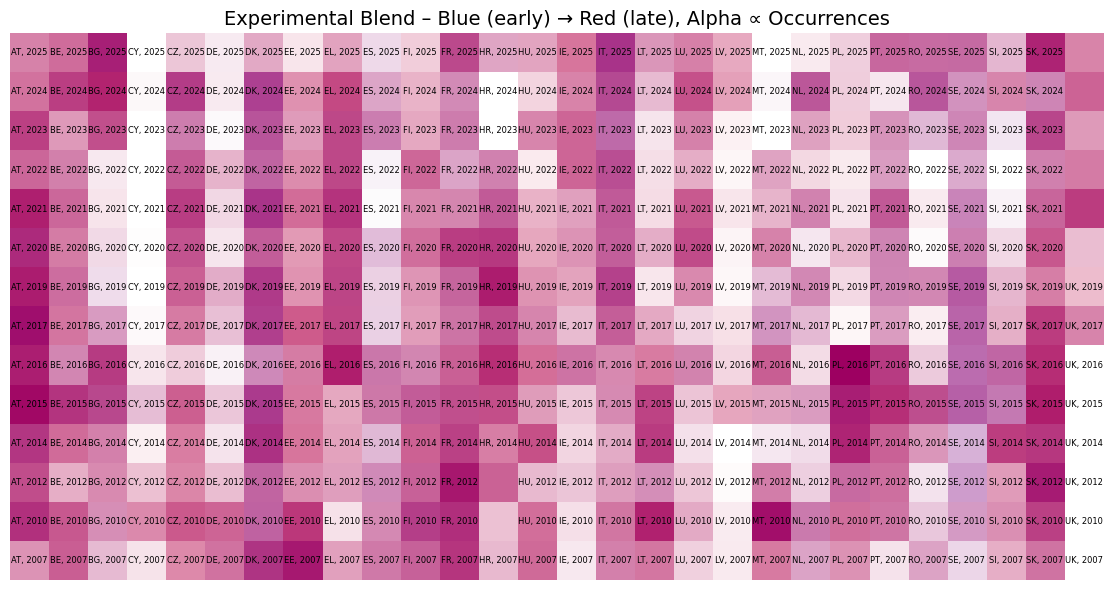

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
from matplotlib.colors import to_rgba

# ---------------------------------------------------------------------------
# 1. Load countries and years from Excel (same as before)
# ---------------------------------------------------------------------------
file_path = 'EU_dataset/Cleaned_Parlemeter_Data-LeftRight.xlsx'
sheet_names = pd.ExcelFile(file_path).sheet_names
sheet_names.remove('RowHeader')

country_years = {}
for sheet in sheet_names:
    country = sheet.split('-')[0].strip()
    df_temp = pd.read_excel(file_path, sheet_name=sheet, header=None, nrows=1)
    years = df_temp.iloc[0].dropna().astype(int).tolist()
    country_years[country] = years

all_years = sorted(set().union(*country_years.values()))
countries = sorted(country_years.keys())

year_to_row = {year: i for i, year in enumerate(all_years)}
country_to_col = {country: j for j, country in enumerate(countries)}

n_rows = len(all_years)
n_cols = len(countries)

# ---------------------------------------------------------------------------
# 2. Parse matches column once (very fast)
# ---------------------------------------------------------------------------
def parse_matches(match_str):
    if pd.isna(match_str):
        return []
    parts = re.split(r'\s*&&\s*', match_str.strip())
    pairs = []
    for part in parts:
        part = part.strip()
        if part.startswith('{') and part.endswith('}'):
            inner = part[1:-1].strip()
            tokens = inner.split()
            if len(tokens) == 2:
                c, y_str = tokens
                try:
                    y = int(y_str)
                    if c in country_to_col and y in year_to_row:
                        pairs.append((year_to_row[y], country_to_col[c]))
                except ValueError:
                    continue
    return pairs

# Pre‑compute for each frame: a set of (row, col) indices
frame_cells = []  # list of sets
for match_str in bsearch_df['matches']:
    pairs = parse_matches(match_str)
    frame_cells.append(set(pairs) if pairs else set())

total_counts = np.zeros((n_rows, n_cols), dtype=int)
cell_times = {}  # (r,c) -> list of time indices

for time_idx, cell_set in enumerate(frame_cells):
    for (r, c) in cell_set:
        total_counts[r, c] += 1
        cell_times.setdefault((r, c), []).append(time_idx)

max_count = total_counts.max() if total_counts.max() > 0 else 1
max_time = len(frame_cells) - 1

# ---------------------------------------------------------------------------
# 3. Build static text labels (used in all plots)
# ---------------------------------------------------------------------------
cell_text = np.empty((n_rows, n_cols), dtype=object)
for i, year in enumerate(all_years):
    for j, country in enumerate(countries):
        if year in country_years.get(country, []):
            cell_text[i, j] = f"{country}, {year}"
        else:
            cell_text[i, j] = ""

# ---------------------------------------------------------------------------
# 4. Static summed (opacity ∝ total count) – using imshow for speed
# ---------------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(max(10, n_cols*0.8), max(6, n_rows*0.4)))
ax1.axis('off')

# Background image: use a gray color with varying alpha
# We'll create an RGBA image: white background with alpha = normalized count
alpha_matrix = total_counts / max_count
# Use a uniform gray (0.5) with alpha
image_data = np.zeros((n_rows, n_cols, 4))
image_data[:, :, 0] = 0.5  # R
image_data[:, :, 1] = 0.5  # G
image_data[:, :, 2] = 0.5  # B
image_data[:, :, 3] = alpha_matrix  # A

im1 = ax1.imshow(image_data, aspect='equal', origin='upper', extent=[0, n_cols, 0, n_rows])

# Add text labels (static)
for i in range(n_rows):
    for j in range(n_cols):
        if cell_text[i, j]:
            ax1.text(j + 0.5, i + 0.5, cell_text[i, j],
                     ha='center', va='center', fontsize=6, color='black')

ax1.set_xticks(np.arange(n_cols) + 0.5)
ax1.set_xticklabels(countries, rotation=45, ha='right')
ax1.set_yticks(np.arange(n_rows) + 0.5)
ax1.set_yticklabels(all_years)
ax1.set_title('Static Summed – Opacity ∝ Occurrences', fontsize=14)
plt.tight_layout()
plt.show()
# fig1.savefig('static_summed_optimized.png', dpi=300, bbox_inches='tight')

# ---------------------------------------------------------------------------
# 5. Timelapse frames – efficient update using imshow
# ---------------------------------------------------------------------------
def generate_frames_optimized(output_dir='data/BehaviorSearch-Thresholded/frames', start=0, end=None, step=1):
    """
    Generate frames from 'start' to 'end' with given step.
    Each frame saves a PNG in output_dir.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # Create figure and axes once
    fig, ax = plt.subplots(figsize=(max(10, n_cols*0.8), max(6, n_rows*0.4)))
    ax.axis('off')
    
    # Background image: white with alpha = 0 initially (transparent)
    image_data = np.zeros((n_rows, n_cols, 4))
    image_data[:, :, :3] = 1.0  # white
    image_data[:, :, 3] = 0.0   # fully transparent
    
    im = ax.imshow(image_data, aspect='equal', origin='upper', extent=[0, n_cols, 0, n_rows])
    
    # Add static text labels (only for valid cells)
    for i in range(n_rows):
        for j in range(n_cols):
            if cell_text[i, j]:
                ax.text(j + 0.5, i + 0.5, cell_text[i, j],
                        ha='center', va='center', fontsize=6, color='black')
    
    ax.set_xticks(np.arange(n_cols) + 0.5)
    ax.set_xticklabels(countries, rotation=45, ha='right')
    ax.set_yticks(np.arange(n_rows) + 0.5)
    ax.set_yticklabels(all_years)
    
    # Loop over frames
    if end is None:
        end = len(frame_cells)
    for t in range(start, end, step):
        # Prepare color matrix: yellow for active cells, transparent for others
        # We'll use RGB (1,1,0) yellow with alpha = 1, others alpha = 0
        active_set = frame_cells[t]
        # Reset image to transparent
        img = np.zeros((n_rows, n_cols, 4))
        img[:, :, :3] = 1.0  # white background
        img[:, :, 3] = 0.0
        # Fill active cells with yellow
        for (r, c) in active_set:
            img[r, c, :3] = (1.0, 1.0, 0.0)  # yellow
            img[r, c, 3] = 1.0
        im.set_data(img)
        ax.set_title(f'Time step {t}')
        plt.tight_layout()
        # Save frame
        plt.savefig(f'{output_dir}/frame_{t:04d}.png', dpi=150, bbox_inches='tight')
        if t % 1 == 0:
            print(f'Generated frame {t}')
    plt.close(fig)

# Example: generate every 5th frame to reduce number (or use step=1 for all)
# generate_frames_optimized('timelapse_frames', step=1)  # change step if needed

# ---------------------------------------------------------------------------
# 6. Experimental blend (blue → red, alpha ∝ total count)
# ---------------------------------------------------------------------------
# Compute average time for each cell
cell_avg_time = np.full((n_rows, n_cols), np.nan)
for (r, c), times in cell_times.items():
    if times:
        cell_avg_time[r, c] = np.mean(times)

# Normalize time to [0,1]
norm_time = np.zeros_like(cell_avg_time)
if max_time > 0:
    norm_time = np.divide(cell_avg_time, max_time, out=np.zeros_like(cell_avg_time), where=~np.isnan(cell_avg_time))
# Blend function: blue (0,0,1) -> red (1,0,0)
def blend(t):
    return (t, 0, 1-t)  # RGB

# Build RGBA image
blend_img = np.zeros((n_rows, n_cols, 4))
for i in range(n_rows):
    for j in range(n_cols):
        if total_counts[i, j] > 0 and not np.isnan(norm_time[i, j]):
            t = norm_time[i, j]
            r, g, b = blend(t)
            alpha = total_counts[i, j] / max_count
            blend_img[i, j] = [r, g, b, alpha]
        else:
            blend_img[i, j] = [1, 1, 1, 0]  # transparent white

fig3, ax3 = plt.subplots(figsize=(max(10, n_cols*0.8), max(6, n_rows*0.4)))
ax3.axis('off')
im3 = ax3.imshow(blend_img, aspect='equal', origin='upper', extent=[0, n_cols, 0, n_rows])
# Add text
for i in range(n_rows):
    for j in range(n_cols):
        if cell_text[i, j]:
            ax3.text(j + 0.5, i + 0.5, cell_text[i, j],
                     ha='center', va='center', fontsize=6, color='black')
ax3.set_xticks(np.arange(n_cols) + 0.5)
ax3.set_xticklabels(countries, rotation=45, ha='right')
ax3.set_yticks(np.arange(n_rows) + 0.5)
ax3.set_yticklabels(all_years)
ax3.set_title('Experimental Blend – Blue (early) → Red (late), Alpha ∝ Occurrences', fontsize=14)
plt.tight_layout()
plt.show()
# fig3.savefig('experimental_blend_optimized.png', dpi=300, bbox_inches='tight')

In [15]:
# bsearch_df[]

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os

# ---------------------------------------------------------------------------
# 1. Load countries and years from Excel
# ---------------------------------------------------------------------------
file_path = 'EU_dataset/Cleaned_Parlemeter_Data-LeftRight.xlsx'
sheet_names = pd.ExcelFile(file_path).sheet_names

# Remove 'RowHeader' if present
if 'RowHeader' in sheet_names:
    sheet_names.remove('RowHeader')

country_years = {}
for sheet in sheet_names:
    country = sheet.split('-')[0].strip()
    df_temp = pd.read_excel(file_path, sheet_name=sheet, header=None, nrows=1)
    years = df_temp.iloc[0].dropna().astype(int).tolist()
    country_years[country] = years

all_years = sorted(set().union(*country_years.values()))

# ---------------------------------------------------------------------------
# 2. Define custom country order (or use alphabetical as fallback)
# ---------------------------------------------------------------------------
custom_country_order = ['BE',
 'DK',
 'DE',
 'EL',
 'ES',
 'FR',
 'IE',
 'IT',
 'LU',
 'NL',
 'AT',
 'PT',
 'FI',
 'SE',
 'UK',
 'BG',
 'CZ',
 'EE',
 'CY',
 'LV',
 'LT',
 'HU',
 'MT',
 'PL',
 'RO',
 'SI',
 'SK',
 'HR']

# Use custom order if all countries are present, otherwise use alphabetical
available_countries = sorted(country_years.keys())
if all(country in available_countries for country in custom_country_order):
    countries = custom_country_order
    print("Using custom country order")
else:
    countries = available_countries
    print("Using alphabetical country order (some custom countries not available)")
    missing = [c for c in custom_country_order if c not in available_countries]
    print(f"Missing countries: {missing}")

# Create mapping from country to column index
country_to_col = {country: i for i, country in enumerate(countries)}
year_to_row = {year: i for i, year in enumerate(all_years)}

n_rows = len(all_years)
n_cols = len(countries)

print(f"Table dimensions: {n_rows} rows × {n_cols} columns")
print(f"Countries in order: {countries}")
print(f"Years: {all_years}")

# ---------------------------------------------------------------------------
# 3. Pre‑compute valid frames: only rows with Thresholded counts >= 1
# ---------------------------------------------------------------------------
def parse_matches(match_str):
    """Return list of (row, col) tuples for a match string."""
    if pd.isna(match_str):
        return []
    parts = re.split(r'\s*&&\s*', match_str.strip())
    pairs = []
    for part in parts:
        part = part.strip()
        if part.startswith('{') and part.endswith('}'):
            inner = part[1:-1].strip()
            tokens = inner.split()
            if len(tokens) == 2:
                country, year_str = tokens
                try:
                    year = int(year_str)
                    if country in country_to_col and year in year_to_row:
                        row_idx = year_to_row[year]
                        col_idx = country_to_col[country]
                        # Bounds check
                        if row_idx < n_rows and col_idx < n_cols:
                            pairs.append((row_idx, col_idx))
                        else:
                            print(f"Warning: ({country}, {year}) -> ({row_idx}, {col_idx}) out of bounds")
                except ValueError:
                    continue
    return pairs

# Get list of (original_index, highlight_cells) for rows that pass filters
valid_rows = []  # list of (orig_idx, highlight_cells)

for idx, row in bsearch_df.iterrows():
    match_str = row['matches']
    thresh_count = row.get(bsearch_df.columns[2], 0)  # default 0 if column missing
    
    # Skip if Thresholded counts < 1
    if thresh_count < 1:
        continue
    
    cells = parse_matches(match_str)
    if cells:  # only keep if at least one pair found
        valid_rows.append((idx, cells))
    else:
        # Print warning if match string parsing yielded nothing
        if pd.notna(match_str):
            print(f"Warning: row {idx} has Thresholded count >=1 but no valid pairs: '{match_str}'")

print(f"Total rows in df: {len(bsearch_df)}")
print(f"Valid rows (Thresholded counts>=1 and parsed cells): {len(valid_rows)}")

# ---------------------------------------------------------------------------
# 4. Helper: build a table figure with highlights
# ---------------------------------------------------------------------------
def build_highlight_table(highlight_cells):
    """Create a table with yellow background for given (row, col) cells."""
    # Build cell text matrix
    cell_text = np.empty((n_rows, n_cols), dtype=object)
    for i, year in enumerate(all_years):
        for j, country in enumerate(countries):
            if year in country_years.get(country, []):
                cell_text[i, j] = f"{country}, {year}"
            else:
                cell_text[i, j] = ""

    fig, ax = plt.subplots(figsize=(max(10, n_cols*0.8), max(6, n_rows*0.4)))
    ax.axis('off')

    # Create table
    table = ax.table(cellText=cell_text,
                     rowLabels=all_years,
                     colLabels=countries,
                     loc='center',
                     cellLoc='center',
                     colWidths=[0.08] * n_cols)

    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(0.4, 1.2)  # your preferred scaling

    # Style headers
    for (row, col), cell in table.get_celld().items():
        if row == 0:  # column headers
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#40466e')
        elif col == -1:  # row headers
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#f0f0f0')
        else:
            # Data cells default white
            cell.set_facecolor('white')
            cell.set_text_props(color='black')

    # Highlight requested cells
    highlighted_count = 0
    for (r, c) in highlight_cells:
        try:
            # Table cell indices: data cell (r,c) -> table position (r+1, c)
            cell = table[(r+1, c)]
            cell.set_facecolor('yellow')
            cell.set_text_props(color='black')
            highlighted_count += 1
        except KeyError:
            print(f"Warning: Cell ({r}, {c}) not found in table.")
            continue
    
    if highlighted_count == 0:
        print(f"WARNING: No cells were highlighted! highlight_cells: {highlight_cells}")

    return fig, ax

# ---------------------------------------------------------------------------
# 5. Generate and save frames only for valid rows
# ---------------------------------------------------------------------------
output_dir = 'frames_valid_rows'
os.makedirs(output_dir, exist_ok=True)

# Optionally limit for testing (remove the slice for full run)
# valid_rows_subset = valid_rows[:10]  # uncomment to test

for frame_number, (orig_idx, highlight_cells) in enumerate(valid_rows):
    # Debug: print how many cells are highlighted
    print(f"Frame {frame_number+1}: original index {orig_idx}, highlighted {len(highlight_cells)} cells")
    
    fig, ax = build_highlight_table(highlight_cells)
    ax.set_title(f'Frame {frame_number+1} (orig row {orig_idx})', fontsize=12)
    plt.tight_layout()
    
    save_path = f'{output_dir}/frame_{frame_number+1:04d}_orig{orig_idx}.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close(fig)

    if (frame_number + 1) % 50 == 0:
        print(f"Saved {frame_number+1} frames so far...")

print(f"Done. Saved {len(valid_rows)} frames to '{output_dir}'.")

Using custom country order
Table dimensions: 14 rows × 28 columns
Countries in order: ['BE', 'DK', 'DE', 'EL', 'ES', 'FR', 'IE', 'IT', 'LU', 'NL', 'AT', 'PT', 'FI', 'SE', 'UK', 'BG', 'CZ', 'EE', 'CY', 'LV', 'LT', 'HU', 'MT', 'PL', 'RO', 'SI', 'SK', 'HR']
Years: [2007, 2010, 2012, 2014, 2015, 2016, 2017, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Total rows in df: 1869
Valid rows (Thresholded counts>=1 and parsed cells): 1354
Frame 1: original index 104, highlighted 20 cells
Frame 2: original index 105, highlighted 20 cells
Frame 3: original index 106, highlighted 17 cells
Frame 4: original index 179, highlighted 166 cells
Frame 5: original index 180, highlighted 150 cells
Frame 6: original index 181, highlighted 174 cells
Frame 7: original index 245, highlighted 96 cells
Frame 8: original index 246, highlighted 82 cells
Frame 9: original index 247, highlighted 121 cells
Frame 10: original index 258, highlighted 1 cells
